# Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import matplotlib
matplotlib.use("Agg")  
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display
matplotlib.rcParams.update({"figure.dpi": 150})

from config import (
    SHAP_DIR, FIGURES_DIR, EVALUATION_DIR,
    DATA_SPLITS_DIR, SMOTE_CONFIGS
)
print("Setup selesai.")

Setup selesai.


# Menampilkan Ringkasan Global Importance

In [2]:
df_global = pd.read_csv(SHAP_DIR / "global_importance_all.csv",
                        index_col=0)
print("=== GLOBAL IMPORTANCE (Mean |SHAP|) PER KONFIGURASI ===\n")
print(df_global.round(6).to_string())

=== GLOBAL IMPORTANCE (Mean |SHAP|) PER KONFIGURASI ===

                     baseline   smote_1   smote_2   smote_3
amount               0.028034  0.065435  0.160586  0.192975
amountToBalanceOrig  0.322830  0.323619  0.774800  2.037460
errorBalanceDest     0.006461  0.019592  0.154286  0.110840
errorBalanceOrig     0.463394  0.795141  1.800876  1.668781
newbalanceDest       0.004893  0.023099  0.033190  0.096365
newbalanceOrig       0.139641  0.269799  0.891144  1.007223
oldbalanceDest       0.018464  0.065760  0.094092  0.131006
oldbalanceOrg        0.017141  0.292043  0.425544  0.567060
transaction_day      0.007927  0.075390  0.061778  0.201764
transaction_hour     0.004049  0.030745  0.067456  0.063212
type_CASH_IN         0.021823  0.002460  0.080251  0.311380
type_CASH_OUT        0.016187  0.030819  0.088059  0.089840
type_DEBIT           0.001993  0.001675  0.026053  0.004547
type_PAYMENT         0.123360  0.116707  0.271191  0.600596
type_TRANSFER        0.007906  0.025430  0.

# Ringkasan Konsistensi

In [3]:
with open(SHAP_DIR / "consistency_metrics.json") as f:
    cons = json.load(f)

print("\n=== RINGKASAN KONSISTENSI PER KONFIGURASI ===\n")
df_cons = pd.DataFrame(cons["summary_per_config"])
print(df_cons[[
    "config", "spearman_vs_baseline", "meets_spearman",
    "cv_top5_features", "meets_cv",
    "jaccard_vs_baseline", "meets_jaccard",
    "meets_all_consistency"
]].to_string(index=False))


=== RINGKASAN KONSISTENSI PER KONFIGURASI ===

  config  spearman_vs_baseline  meets_spearman  cv_top5_features meets_cv  jaccard_vs_baseline  meets_jaccard meets_all_consistency
baseline                1.0000            True            0.7514    False               1.0000           True                 False
 smote_1                0.7607           False            0.7562    False               0.6667           True                 False
 smote_2                0.8571            True            0.7562    False               0.6667           True                 False
 smote_3                0.9036            True            0.7562    False               0.6667           True                 False


# Konfigurasi Optimal Akhir

In [4]:
with open(EVALUATION_DIR / "best_config_final.json") as f:
    best = json.load(f)

shap_section = best.get("shap_analysis", {})
print("\n=== KONFIGURASI OPTIMAL BERDASARKAN KINERJA + KONSISTENSI ===\n")
print(f"Konfigurasi terpilih : {shap_section.get('optimal_config_shap')}")
print(f"Alasan               : {shap_section.get('selection_reason')}")
perf = shap_section.get("performance_metrics", {})
cons_m = shap_section.get("consistency_metrics", {})
print(f"\nKinerja  : PR-AUC={perf.get('pr_auc')} | "
      f"F1={perf.get('f1')} | Recall={perf.get('recall')}")
print(f"Konsistensi: Spearman={cons_m.get('spearman_vs_baseline')} | "
      f"CV_top5={cons_m.get('cv_top5')} | "
      f"Jaccard={cons_m.get('jaccard_vs_baseline')}")


=== KONFIGURASI OPTIMAL BERDASARKAN KINERJA + KONSISTENSI ===

Konfigurasi terpilih : baseline
Alasan               : Tidak ada konfigurasi yang memenuhi semua target kinerja DAN konsistensi sekaligus. Dipilih konfigurasi yang memenuhi target kinerja dengan konsistensi SHAP terbaik.

Kinerja  : PR-AUC=0.9995 | F1=0.9981 | Recall=0.9992
Konsistensi: Spearman=1.0 | CV_top5=0.7514 | Jaccard=1.0


# Contoh Local Explanation (Fraud Aktual)

In [5]:
with open(SHAP_DIR / "local_explanations_sample.json") as f:
    local_expls = json.load(f)

# Menampilkan 2 contoh dari best config
best_cfg = shap_section.get("optimal_config_shap", "smote_1")
samples  = local_expls.get(best_cfg, [])[:2]

print(f"\n=== CONTOH LOCAL EXPLANATION ({best_cfg}) ===\n")
for expl in samples:
    print(f"Transaction ID : {expl['transaction_id']}")
    print(f"Fraud Score    : {expl['fraud_score']:.4f}")
    print(f"Decision       : {expl['decision']}")
    print(f"Penjelasan     : {expl['natural_language_explanation']}")
    print(f"Top features   :")
    for f in expl["top_features"]:
        print(f"  {f['rank']}. {f['feature']:<25} "
              f"SHAP={f['shap_value']:+.4f} | "
              f"val={f['feature_value']:.4f} | "
              f"{f['direction']}")
    print(f"SHAP Hash (top-3): {expl['shap_hash_top3']}")
    print("-"*60)


=== CONTOH LOCAL EXPLANATION (baseline) ===

Transaction ID : TEST-0857263
Fraud Score    : 0.7394
Decision       : FRAUD
Penjelasan     : Transaksi ini diidentifikasi sebagai fraud karena: Terdapat inkonsistensi signifikan antara saldo dan nominal transaksi pengirim; Nominal transaksi tidak proporsional terhadap saldo pengirim; Saldo akhir pengirim menunjukkan pola tidak wajar; Saldo awal pengirim memiliki pola berisiko; dan Tipe transaksi TRANSFER memiliki asosiasi tinggi dengan pola kecurangan.
Top features   :
  1. errorBalanceOrig          SHAP=+0.4721 | val=0.0000 | increases_fraud_risk
  2. amountToBalanceOrig       SHAP=+0.3602 | val=1.0000 | increases_fraud_risk
  3. newbalanceOrig            SHAP=+0.0987 | val=0.0000 | increases_fraud_risk
  4. oldbalanceOrg             SHAP=+0.0334 | val=797235.0600 | increases_fraud_risk
  5. type_TRANSFER             SHAP=+0.0278 | val=1.0000 | increases_fraud_risk
SHAP Hash (top-3): 0bc4801a3e574b52165f2749f19905af6db200943e9170baaa86441

# Menampilkan Semua Visualisasi


shap_beeswarm_baseline.png:


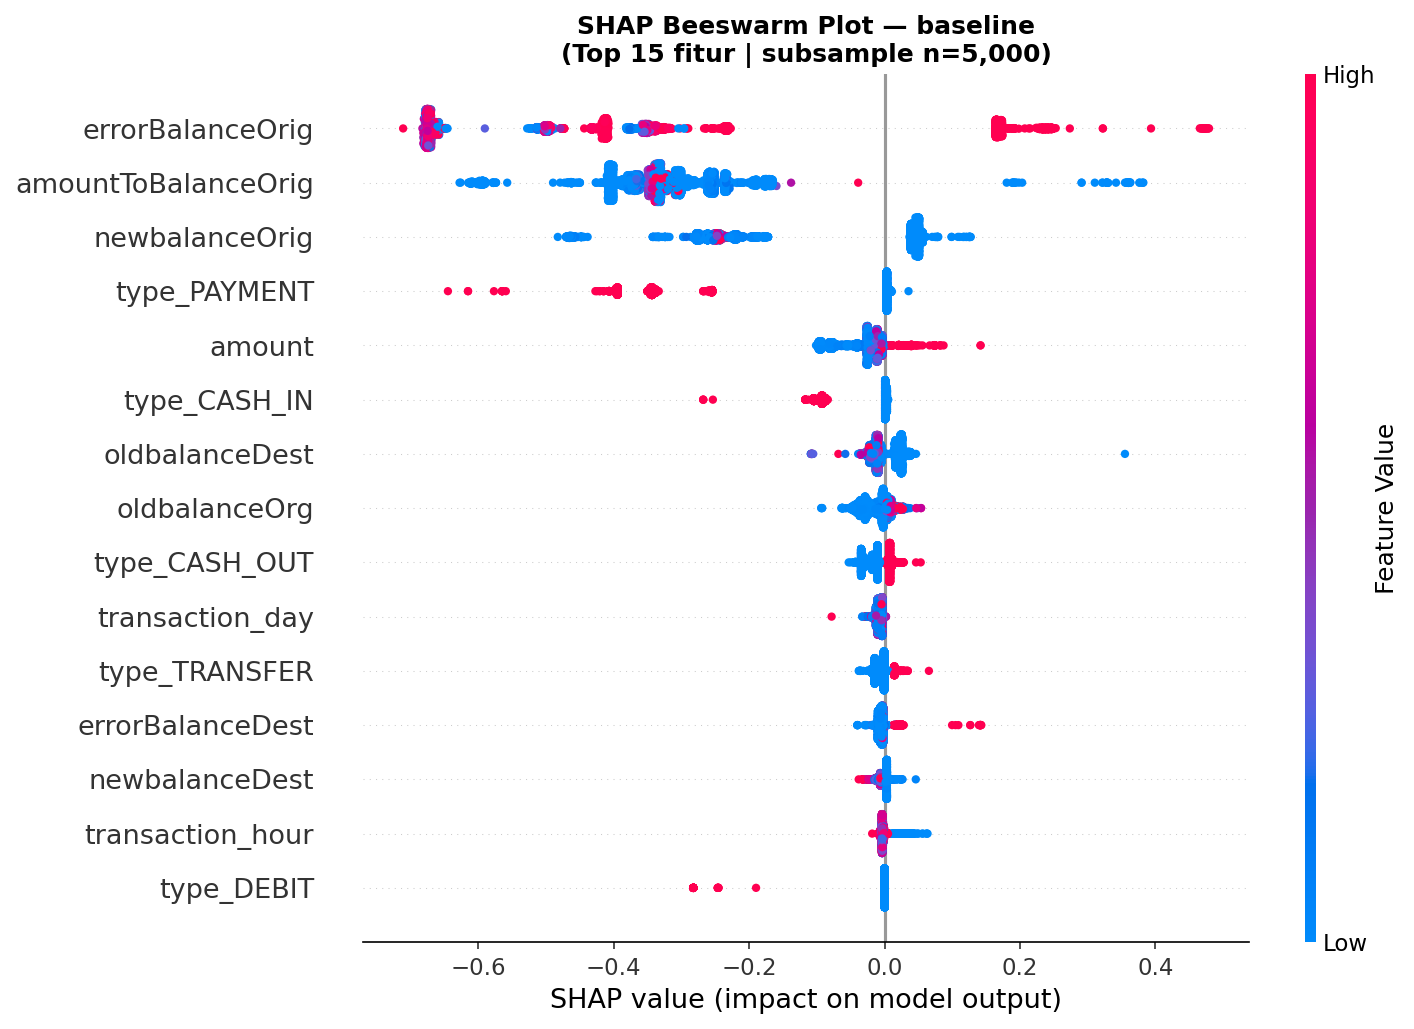


shap_beeswarm_smote_1.png:


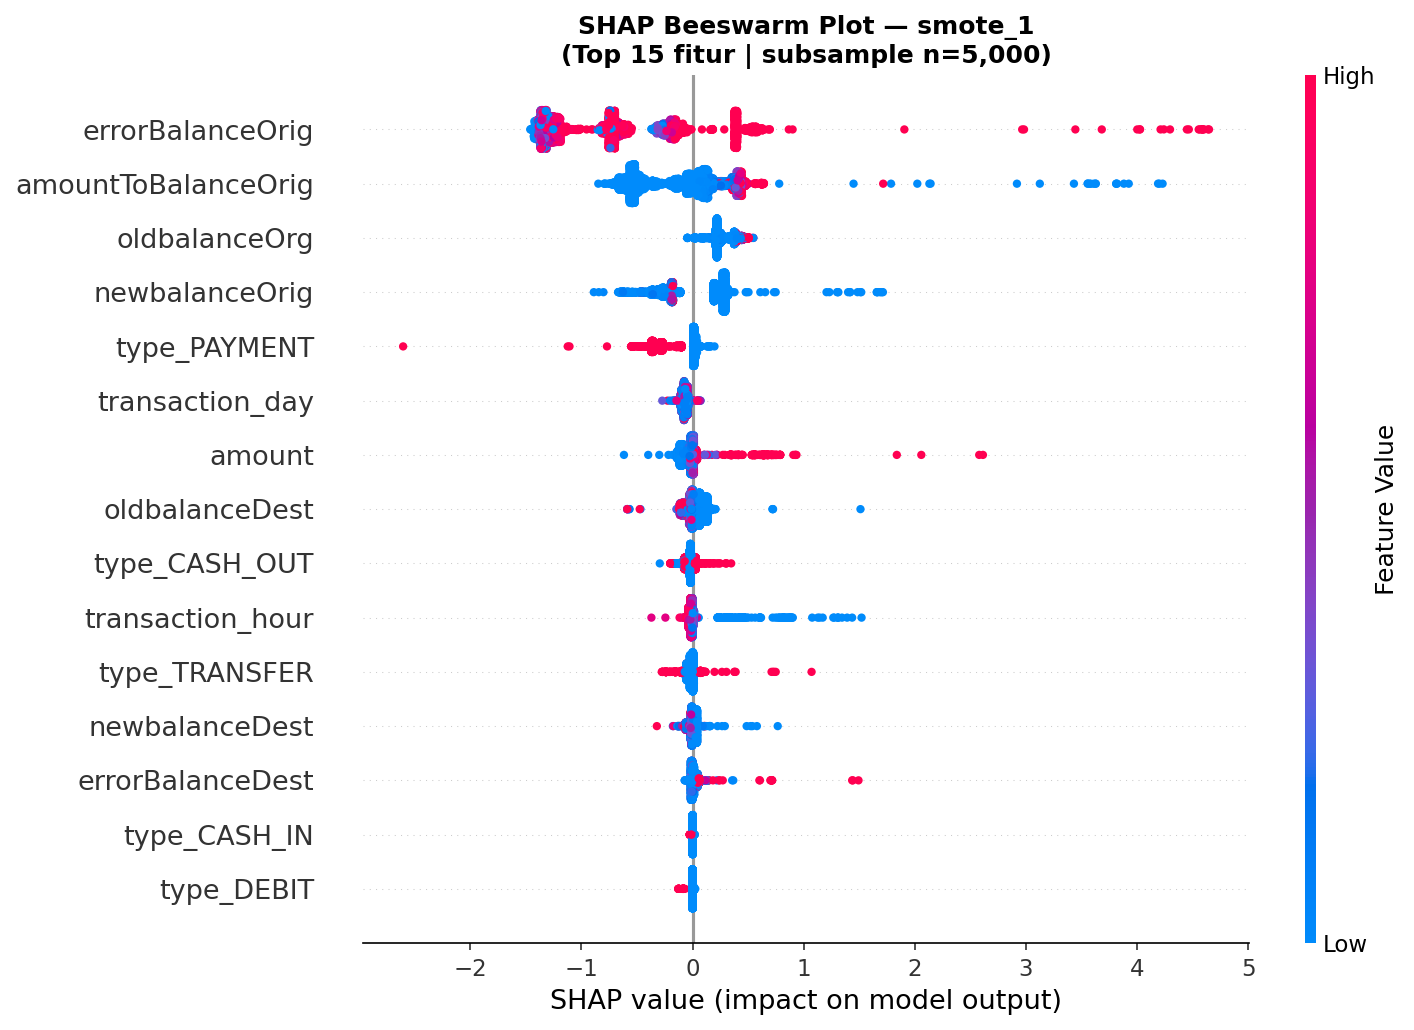


shap_beeswarm_smote_2.png:


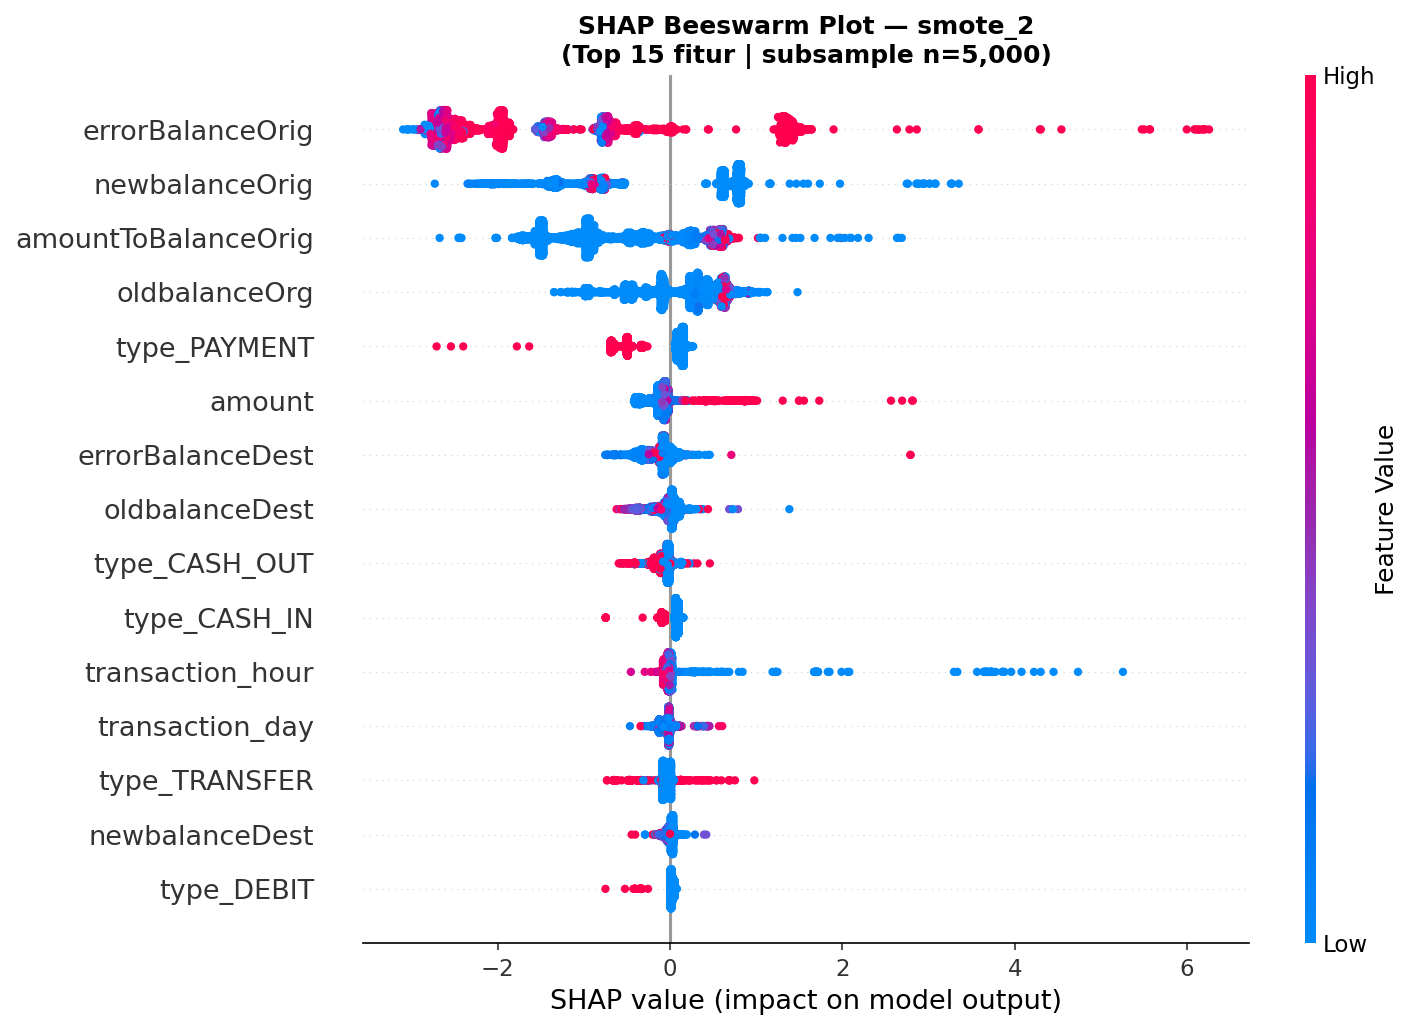


shap_beeswarm_smote_3.png:


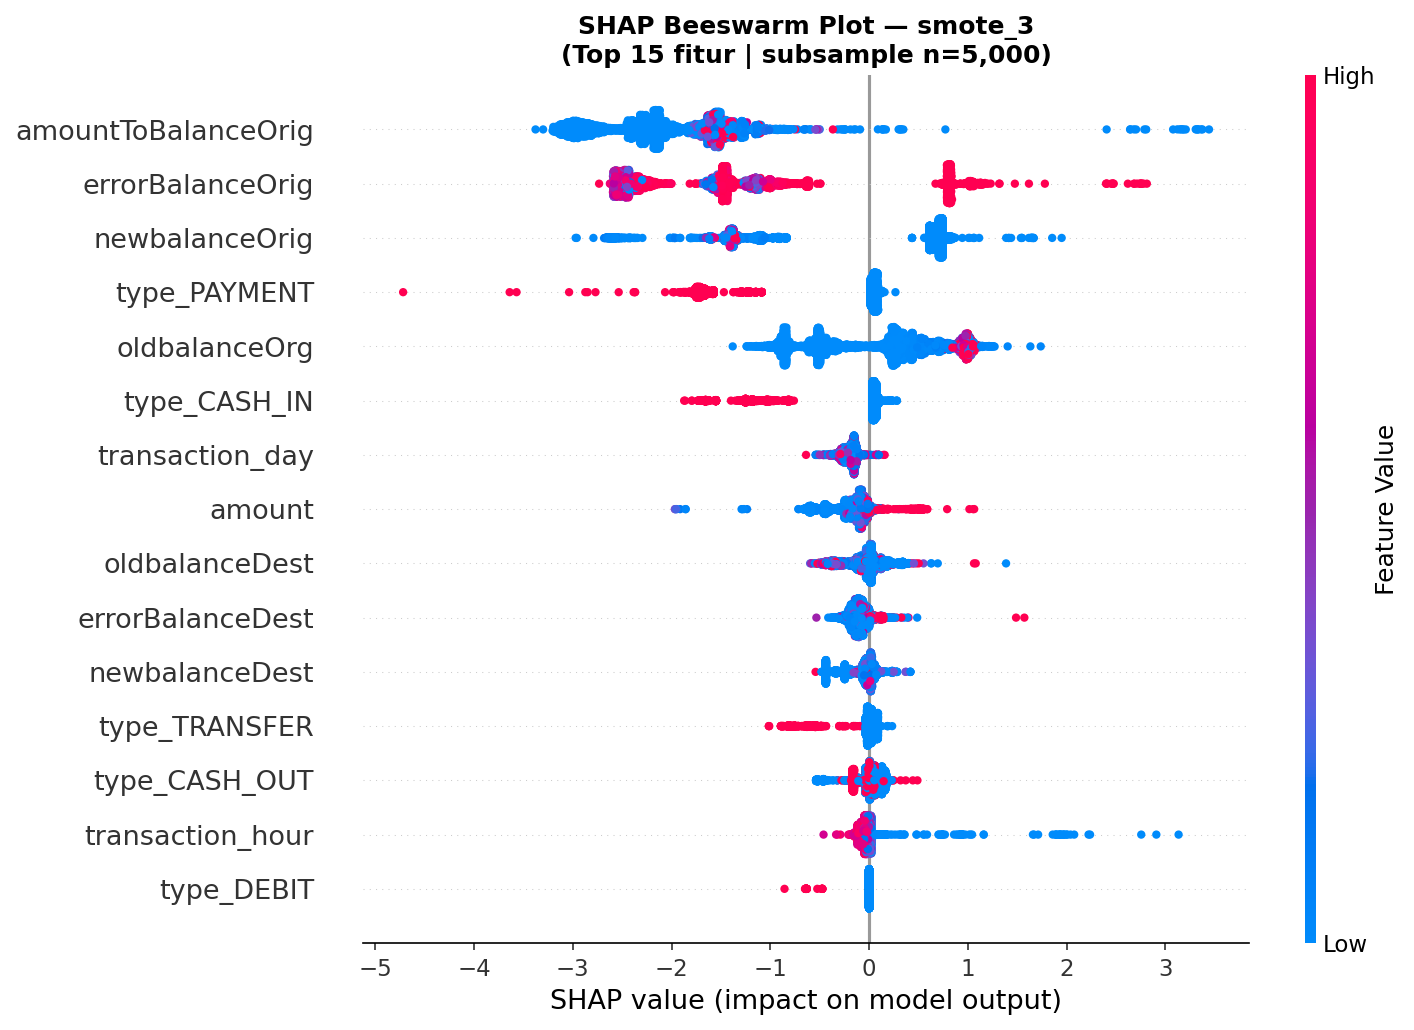


shap_global_comparison.png:


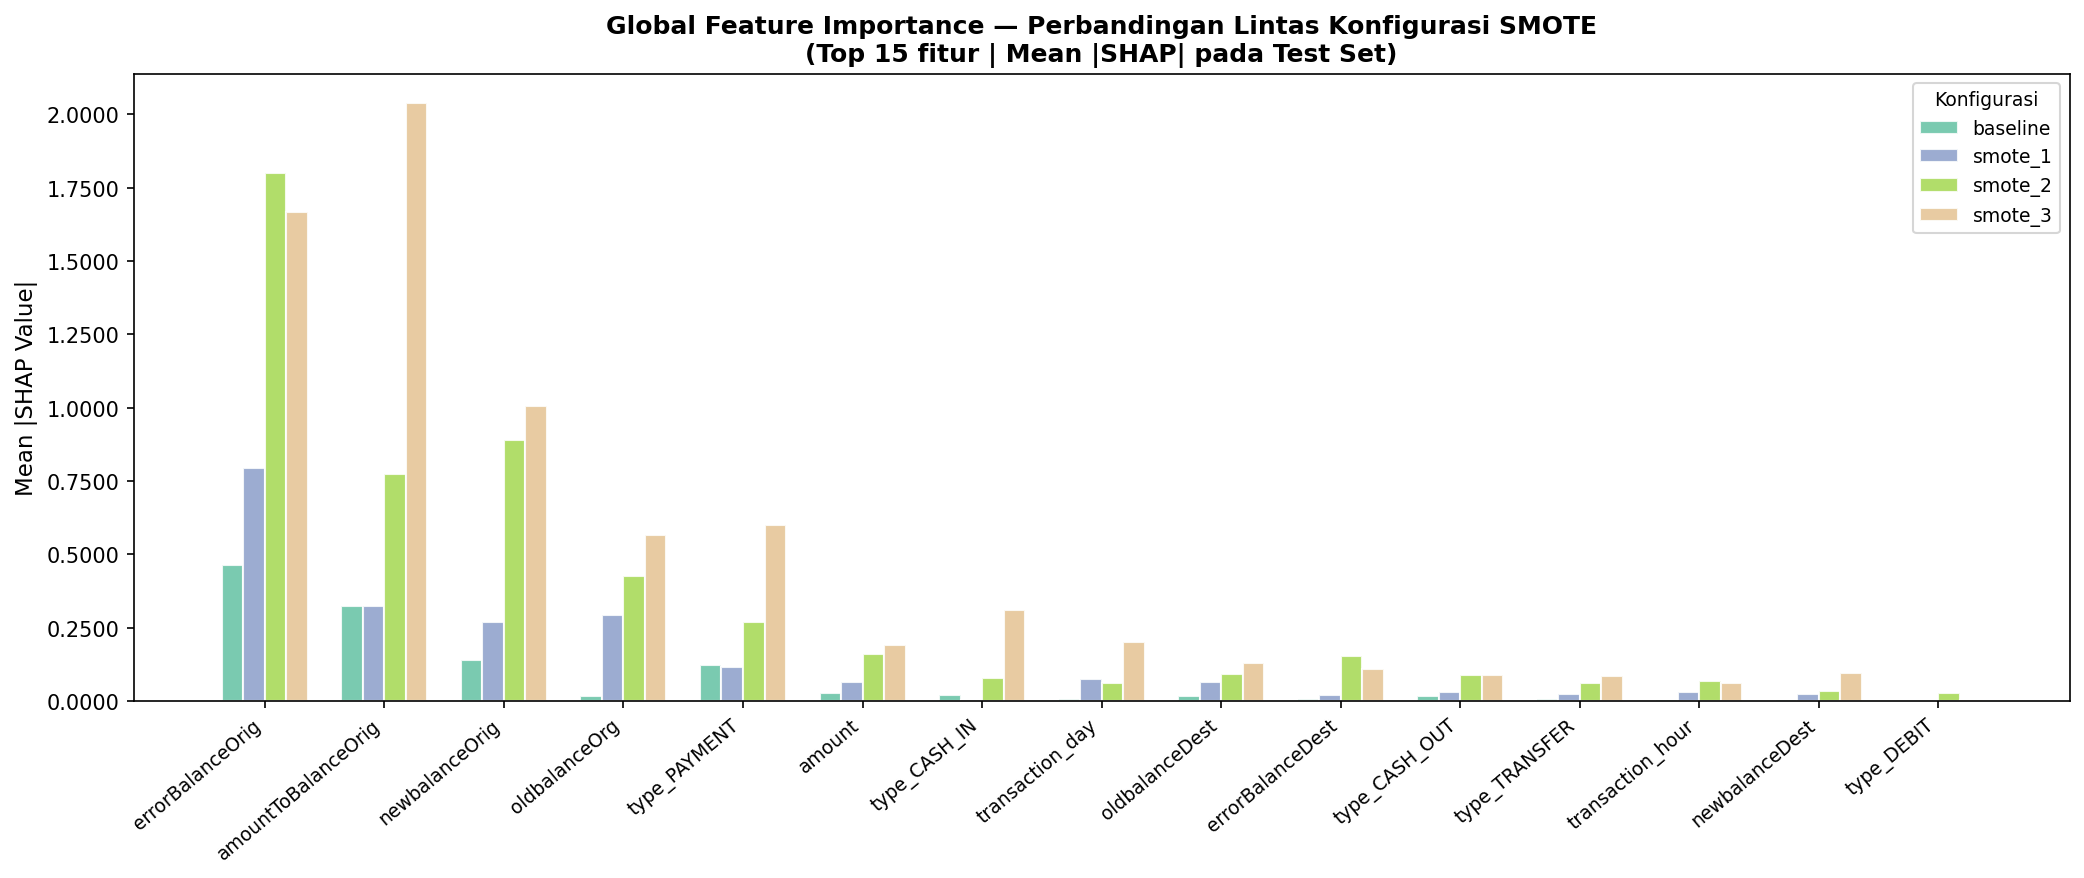


shap_spearman_heatmap.png:


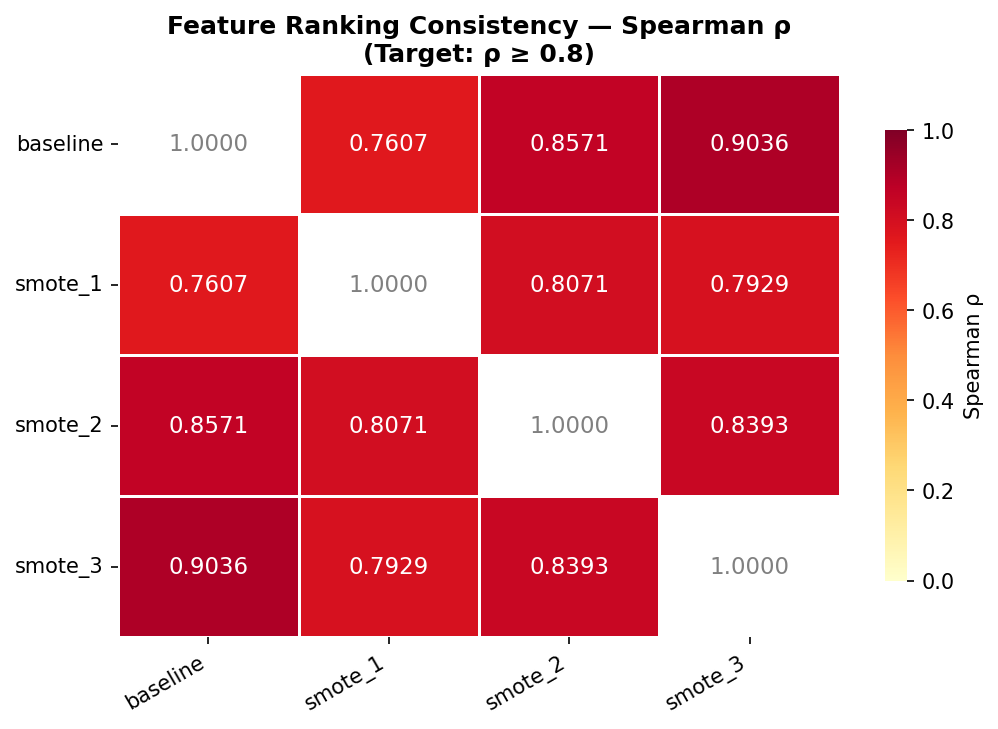


shap_cv_barplot.png:


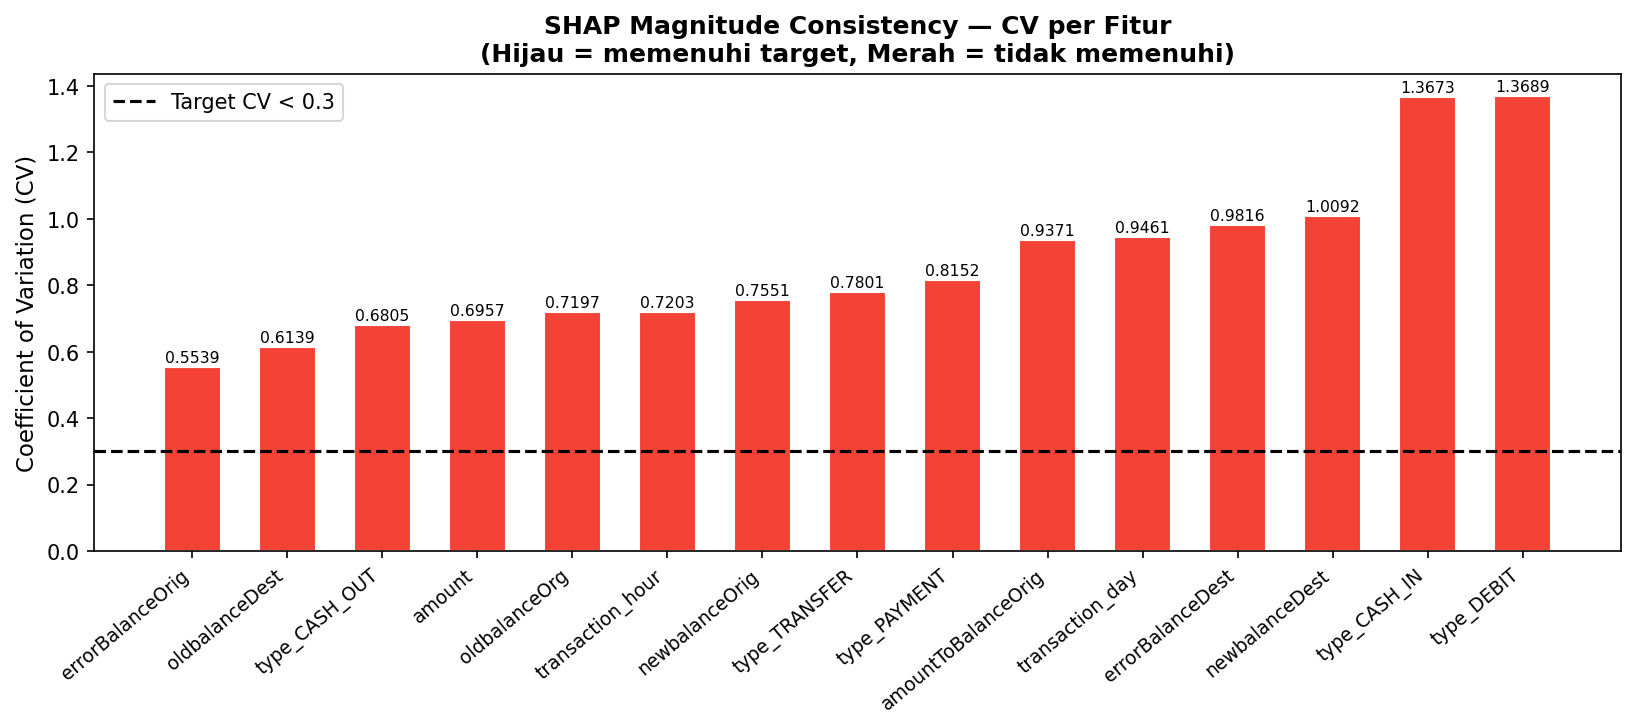


shap_jaccard_heatmap.png:


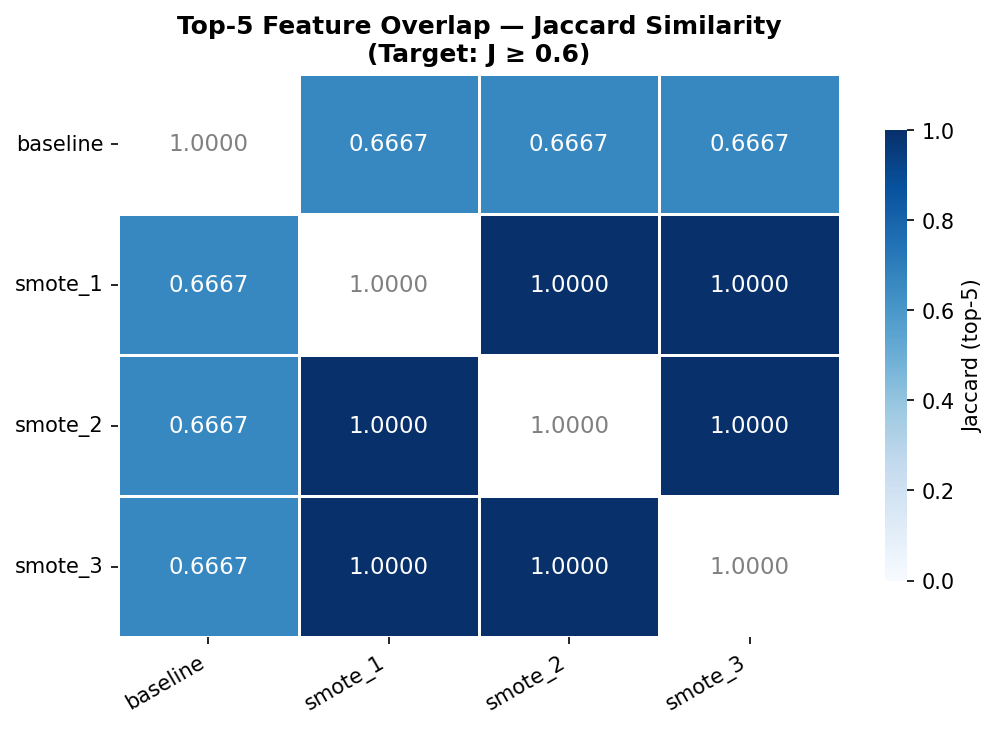

In [6]:
figures = [
    "shap_beeswarm_baseline.png",
    "shap_beeswarm_smote_1.png",
    "shap_beeswarm_smote_2.png",
    "shap_beeswarm_smote_3.png",
    "shap_global_comparison.png",
    "shap_spearman_heatmap.png",
    "shap_cv_barplot.png",
    "shap_jaccard_heatmap.png",
]
for fig_name in figures:
    path = FIGURES_DIR / fig_name
    if path.exists():
        print(f"\n{fig_name}:")
        display(Image(str(path)))
    else:
        print(f"[Belum ada] {fig_name}")